# Battery Degradation: Learning SEI Growth and Capacity Fade

A lithium-ion battery cycling model where the **structure** (SEI growth causing capacity fade) is known but two **mechanistic functions** are unknown and learned from cycling data.

**Known structure:**
```
SEI(n+1) = SEI(n) + k_sei * f_growth(SEI(n)) * dt
Q(n+1)   = Q(n)   - k_cap * SEI(n) * g_fade(Q(n)) * dt
```

**Known:** k_sei=0.1, k_cap=0.05, dt=0.5

**Unknown (learned as MLPs):**
- `f_growth(SEI) = 1/sqrt(0.1 + SEI)` -- parabolic growth law (Softplus output)
- `g_fade(Q) = Q^0.5` -- square root dependence (Sigmoid output)

Training on 8 trajectories at different initial SEI thicknesses (simulating batteries at different calendar ages).

After training: compare learned vs true functions, attempt symbolic regression, verify physical invariants (Q >= 0, Q decreasing, SEI increasing).

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from cajal.syntax import TmIter, TmVar, TmApp, TyNat, TyBool, TyReal
from cajal.compiling import compile, TypedTensor

device = torch.device('cpu')

# Known parameters
K_SEI = 0.1
K_CAP = 0.05
DT = 0.5
Q0 = 1.0
N_STEPS = 10
N_TRAJECTORIES = 8

# Ground truth (hidden from learner)
def true_f_growth(sei):
    """Parabolic growth law: growth rate slows as SEI thickens."""
    return 1.0 / torch.sqrt(0.1 + sei)

def true_g_fade(q):
    """Square root dependence: fade rate depends on remaining capacity."""
    return q ** 0.5


def generate_trajectories():
    sei_inits = torch.linspace(0.05, 0.6, N_TRAJECTORIES)
    curves = []
    for sei0 in sei_inits:
        curve = []
        q, sei = Q0, sei0.item()
        for _ in range(N_STEPS):
            curve.append(torch.tensor([q, sei], dtype=torch.float32))
            sei_new = sei + K_SEI * true_f_growth(torch.tensor(sei)).item() * DT
            q_new = q - K_CAP * sei * true_g_fade(torch.tensor(q)).item() * DT
            sei, q = sei_new, q_new
        curves.append(torch.stack(curve))
    return sei_inits, curves


sei_inits, true_curves = generate_trajectories()
print(f'Device: {device}')
print(f'Generated {N_TRAJECTORIES} trajectories, {N_STEPS} steps each')
print(f'Initial SEI range: [{sei_inits[0]:.2f}, {sei_inits[-1]:.2f}]')

Device: cpu
Generated 8 trajectories, 10 steps each
Initial SEI range: [0.05, 0.60]


In [2]:
class SEIGrowthMLP(nn.Module):
    """f_growth: R -> R+. Softplus ensures strictly positive output."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16), nn.Tanh(),
            nn.Linear(16, 16), nn.Tanh(),
            nn.Linear(16, 1), nn.Softplus(),
        )
    def forward(self, sei):
        return self.net(sei.view(1, 1)).squeeze()


class CapacityFadeMLP(nn.Module):
    """g_fade: R -> [0,1]. Sigmoid ensures bounded output."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16), nn.Tanh(),
            nn.Linear(16, 16), nn.Tanh(),
            nn.Linear(16, 1), nn.Sigmoid(),
        )
    def forward(self, q):
        return self.net(q.view(1, 1)).squeeze()


class BatteryUpdate(nn.Module):
    """One timestep. State: [Q, SEI, sei_init_normalized].
    Structure fixed; only f_growth and g_fade are learnable."""
    def __init__(self, k_sei, k_cap, dt, f_growth_mlp, g_fade_mlp):
        super().__init__()
        self.k_sei, self.k_cap, self.dt = k_sei, k_cap, dt
        self.f_growth, self.g_fade = f_growth_mlp, g_fade_mlp

    def forward(self, state):
        q, sei, sei_init = state.data[0], state.data[1], state.data[2]
        f_g = self.f_growth(sei)
        g_f = self.g_fade(q)
        sei_new = sei + self.k_sei * f_g * self.dt
        q_new = q - self.k_cap * sei * g_f * self.dt
        return TypedTensor(torch.stack([q_new, sei_new, sei_init]), state.ty)


# Cajal program
program = TmIter(TmVar('s0'), 's', TmApp(TmVar('f'), TmVar('s')), TmVar('n'))
compiled = compile(program)

f_growth_mlp = SEIGrowthMLP()
g_fade_mlp = CapacityFadeMLP()
update_fn = BatteryUpdate(K_SEI, K_CAP, DT, f_growth_mlp, g_fade_mlp)
optimizer = torch.optim.Adam(
    list(f_growth_mlp.parameters()) + list(g_fade_mlp.parameters()), lr=0.005
)

n_params = sum(p.numel() for p in f_growth_mlp.parameters()) + \
           sum(p.numel() for p in g_fade_mlp.parameters())
print(f'Two MLPs, {n_params} total parameters')
print(f'Training: {N_TRAJECTORIES} trajectories x {N_STEPS} steps')

losses = []
for epoch in range(500):
    optimizer.zero_grad()
    total_loss = torch.tensor(0.0)

    for traj_idx in range(N_TRAJECTORIES):
        sei0 = sei_inits[traj_idx]
        s0 = TypedTensor(
            torch.stack([torch.tensor(Q0), sei0, sei0]),
            TyReal(3),
        )
        for step in range(N_STEPS):
            n_onehot = torch.zeros(N_STEPS)
            n_onehot[step] = 1.0
            n_val = TypedTensor(n_onehot, TyNat())
            result = compiled({'s0': s0, 'f': lambda s, _fn=update_fn: _fn(s), 'n': n_val})
            total_loss = total_loss + ((result.data[:2] - true_curves[traj_idx][step]) ** 2).sum()

    total_loss.backward()
    optimizer.step()
    losses.append(total_loss.item())

    if epoch % 100 == 0 or epoch == 499:
        print(f'  epoch {epoch:3d}  loss={total_loss.item():.8f}')

print('Training complete')

Two MLPs, 642 total parameters
Training: 8 trajectories x 10 steps
  epoch   0  loss=2.97970557


  epoch 100  loss=0.01589992


  epoch 200  loss=0.01339561


  epoch 300  loss=0.01042532


  epoch 400  loss=0.00719143


  epoch 499  loss=0.00431656
Training complete


In [3]:
# Evaluate learned functions
test_sei = torch.linspace(0.05, 1.0, 50)
test_q = torch.linspace(0.1, 1.0, 50)

with torch.no_grad():
    true_growth = [true_f_growth(s).item() for s in test_sei]
    learned_growth = [f_growth_mlp(s).item() for s in test_sei]
    true_fade = [true_g_fade(q).item() for q in test_q]
    learned_fade = [g_fade_mlp(q).item() for q in test_q]

max_err_growth = max(abs(t - l) for t, l in zip(true_growth, learned_growth))
max_err_fade = max(abs(t - l) for t, l in zip(true_fade, learned_fade))
print(f'f_growth max error: {max_err_growth:.4f}')
print(f'g_fade   max error: {max_err_fade:.4f}')

# Symbolic regression: f_growth
sei_grid = torch.linspace(0.01, 1.5, 200)
with torch.no_grad():
    y_growth = torch.tensor([f_growth_mlp(s).item() for s in sei_grid])

param_grid = torch.linspace(0.01, 2.0, 200)
growth_candidates = {
    '1/sqrt(a + s)': lambda s, a: 1.0 / torch.sqrt(a + s),
    '1/(a + s)':     lambda s, a: 1.0 / (a + s),
    'exp(-a*s)':     lambda s, a: torch.exp(-a * s),
    '1/s^a':         lambda s, a: 1.0 / (s ** a + 1e-8),
    'a / (1 + s)':   lambda s, a: a / (1.0 + s),
}

best_name_g, best_loss_g, best_param_g = None, float('inf'), None
for name, func in growth_candidates.items():
    for pv in param_grid:
        pred = func(sei_grid, pv)
        loss = ((pred - y_growth) ** 2).mean().item()
        if loss < best_loss_g:
            best_loss_g, best_name_g = loss, name
            best_param_g = pv.item()

print(f'\nf_growth symbolic regression: {best_name_g}, param={best_param_g:.3f} (true a=0.100), MSE={best_loss_g:.6f}')

# Symbolic regression: g_fade
q_grid = torch.linspace(0.01, 1.0, 200)
with torch.no_grad():
    y_fade = torch.tensor([g_fade_mlp(q).item() for q in q_grid])

exponent_grid = torch.linspace(0.1, 2.0, 200)
fade_candidates = {
    'Q^a (power law)':    lambda Q, a: Q ** a,
    'Q / (a + Q)':        lambda Q, a: Q / (a + Q),
    'linear: a*Q':        lambda Q, a: a * Q,
    '1 - exp(-a*Q)':      lambda Q, a: 1.0 - torch.exp(-a * Q),
    'sigmoid(a*(Q-0.5))': lambda Q, a: torch.sigmoid(a * (Q - 0.5)),
}

best_name_f, best_loss_f, best_param_f = None, float('inf'), None
for name, func in fade_candidates.items():
    for pv in exponent_grid:
        pred = func(q_grid, pv)
        loss = ((pred - y_fade) ** 2).mean().item()
        if loss < best_loss_f:
            best_loss_f, best_name_f = loss, name
            best_param_f = pv.item()

print(f'g_fade   symbolic regression: {best_name_f}, param={best_param_f:.3f} (true=0.500), MSE={best_loss_f:.6f}')

# Compute symbolic regression predictions for plotting
sym_growth_func = growth_candidates.get(best_name_g)
sym_fade_func = fade_candidates.get(best_name_f)
sym_growth_vals = sym_growth_func(sei_grid, best_param_g).numpy() if sym_growth_func else None
sym_fade_vals = sym_fade_func(q_grid, best_param_f).numpy() if sym_fade_func else None

f_growth max error: 0.5095
g_fade   max error: 0.6412

f_growth symbolic regression: 1/sqrt(a + s), param=0.160 (true a=0.100), MSE=0.008915
g_fade   symbolic regression: Q^a (power law), param=0.100 (true=0.500), MSE=0.008159


In [4]:
# Verification
with torch.no_grad():
    sei_test_v = torch.linspace(0.0, 2.0, 100)
    growth_vals = torch.tensor([f_growth_mlp(s).item() for s in sei_test_v])
    f_growth_positive = (growth_vals > 0).all()

    q_test_v = torch.linspace(0.0, 1.0, 100)
    fade_vals = torch.tensor([g_fade_mlp(q).item() for q in q_test_v])
    g_fade_bounded = (fade_vals >= 0).all() and (fade_vals <= 1).all()

all_q_positive = True
q_monotone_dec = True
sei_monotone_inc = True

with torch.no_grad():
    for traj_idx in range(N_TRAJECTORIES):
        sei0 = sei_inits[traj_idx]
        s0 = TypedTensor(torch.stack([torch.tensor(Q0), sei0, sei0]), TyReal(3))
        prev_q, prev_sei = Q0 + 1.0, -1.0
        for step in range(N_STEPS):
            n_onehot = torch.zeros(N_STEPS)
            n_onehot[step] = 1.0
            result = compiled({'s0': s0, 'f': lambda s, _fn=update_fn: _fn(s),
                               'n': TypedTensor(n_onehot, TyNat())})
            q_val, sei_val = result.data[0].item(), result.data[1].item()
            if q_val < -1e-10: all_q_positive = False
            if q_val > prev_q + 1e-8: q_monotone_dec = False
            if sei_val < prev_sei - 1e-8: sei_monotone_inc = False
            prev_q, prev_sei = q_val, sei_val

print('VERIFICATION:')
print(f"  f_growth(SEI) > 0:            {'VERIFIED' if f_growth_positive else 'FAILED'} (softplus architecture)")
print(f"  g_fade(Q) in [0,1]:           {'VERIFIED' if g_fade_bounded else 'FAILED'} (sigmoid architecture)")
print(f"  Q >= 0 for all trajectories:  {'VERIFIED' if all_q_positive else 'FAILED'}")
print(f"  Q monotonically decreasing:   {'VERIFIED' if q_monotone_dec else 'FAILED'}")
print(f"  SEI monotonically increasing: {'VERIFIED' if sei_monotone_inc else 'FAILED'}")

# Collect trajectory for plotting
pred_q_traj, pred_sei_traj = [], []
with torch.no_grad():
    sei0 = sei_inits[0]
    s0 = TypedTensor(torch.stack([torch.tensor(Q0), sei0, sei0]), TyReal(3))
    for step in range(N_STEPS):
        n_onehot = torch.zeros(N_STEPS)
        n_onehot[step] = 1.0
        result = compiled({'s0': s0, 'f': lambda s, _fn=update_fn: _fn(s),
                           'n': TypedTensor(n_onehot, TyNat())})
        pred_q_traj.append(result.data[0].item())
        pred_sei_traj.append(result.data[1].item())

VERIFICATION:
  f_growth(SEI) > 0:            VERIFIED (softplus architecture)
  g_fade(Q) in [0,1]:           VERIFIED (sigmoid architecture)
  Q >= 0 for all trajectories:  VERIFIED
  Q monotonically decreasing:   VERIFIED
  SEI monotonically increasing: VERIFIED


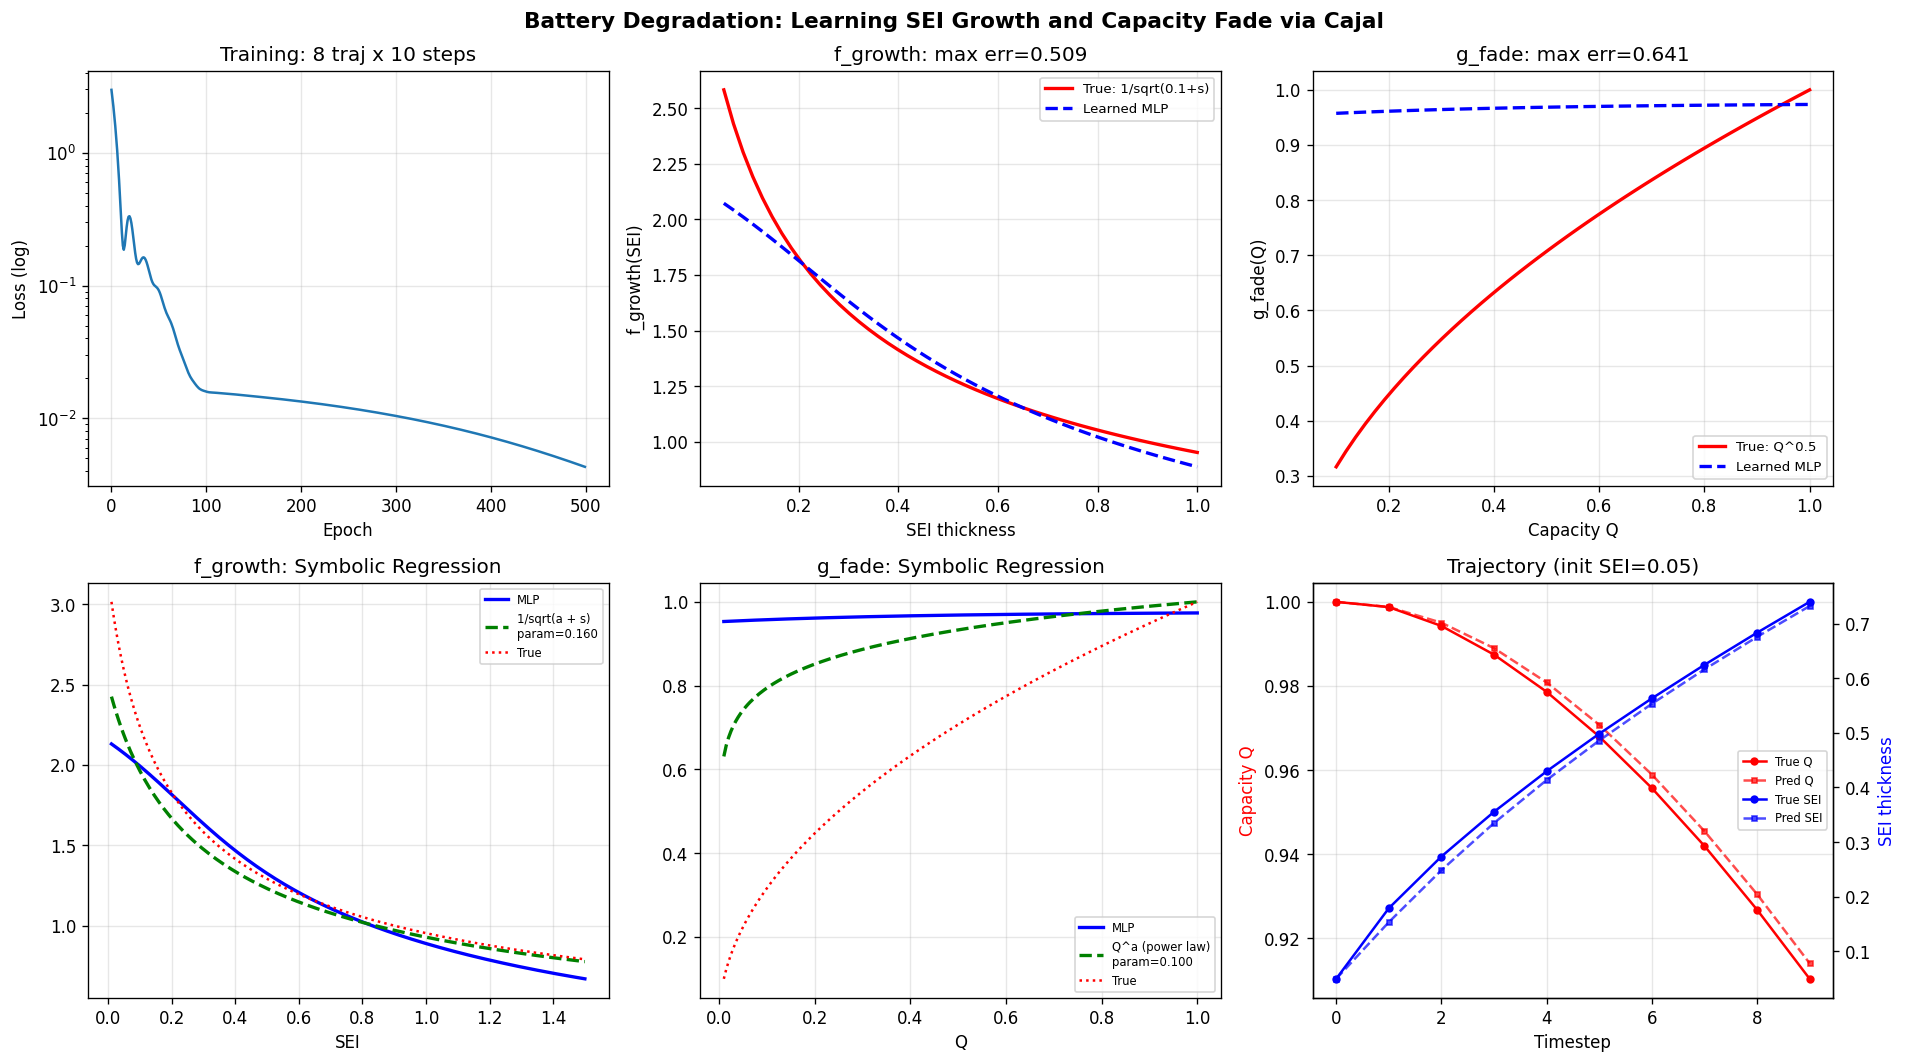

In [5]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1, Col 1: Training loss
axes[0, 0].semilogy(losses)
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss (log)')
axes[0, 0].set_title(f'Training: {N_TRAJECTORIES} traj x {N_STEPS} steps')
axes[0, 0].grid(True, alpha=0.3)

# Row 1, Col 2: Learned f_growth vs true
axes[0, 1].plot(test_sei.numpy(), true_growth, 'r-', lw=2, label='True: 1/sqrt(0.1+s)')
axes[0, 1].plot(test_sei.numpy(), learned_growth, 'b--', lw=2, label='Learned MLP')
axes[0, 1].set_xlabel('SEI thickness'); axes[0, 1].set_ylabel('f_growth(SEI)')
axes[0, 1].set_title(f'f_growth: max err={max_err_growth:.3f}')
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(True, alpha=0.3)

# Row 1, Col 3: Learned g_fade vs true
axes[0, 2].plot(test_q.numpy(), true_fade, 'r-', lw=2, label='True: Q^0.5')
axes[0, 2].plot(test_q.numpy(), learned_fade, 'b--', lw=2, label='Learned MLP')
axes[0, 2].set_xlabel('Capacity Q'); axes[0, 2].set_ylabel('g_fade(Q)')
axes[0, 2].set_title(f'g_fade: max err={max_err_fade:.3f}')
axes[0, 2].legend(fontsize=8); axes[0, 2].grid(True, alpha=0.3)

# Row 2, Col 1: Symbolic regression f_growth
axes[1, 0].plot(sei_grid.numpy(), y_growth.numpy(), 'b-', lw=2, label='MLP')
if sym_growth_vals is not None:
    axes[1, 0].plot(sei_grid.numpy(), sym_growth_vals, 'g--', lw=2,
                    label=f'{best_name_g}\nparam={best_param_g:.3f}')
axes[1, 0].plot(sei_grid.numpy(), [true_f_growth(s).item() for s in sei_grid],
               'r:', lw=1.5, label='True')
axes[1, 0].set_xlabel('SEI'); axes[1, 0].set_title('f_growth: Symbolic Regression')
axes[1, 0].legend(fontsize=7); axes[1, 0].grid(True, alpha=0.3)

# Row 2, Col 2: Symbolic regression g_fade
axes[1, 1].plot(q_grid.numpy(), y_fade.numpy(), 'b-', lw=2, label='MLP')
if sym_fade_vals is not None:
    axes[1, 1].plot(q_grid.numpy(), sym_fade_vals, 'g--', lw=2,
                    label=f'{best_name_f}\nparam={best_param_f:.3f}')
axes[1, 1].plot(q_grid.numpy(), [true_g_fade(q).item() for q in q_grid],
               'r:', lw=1.5, label='True')
axes[1, 1].set_xlabel('Q'); axes[1, 1].set_title('g_fade: Symbolic Regression')
axes[1, 1].legend(fontsize=7); axes[1, 1].grid(True, alpha=0.3)

# Row 2, Col 3: Trajectory comparison
steps = np.arange(N_STEPS)
true_ref = true_curves[0].numpy()
ax = axes[1, 2]
ax.plot(steps, true_ref[:, 0], 'r-o', markersize=4, label='True Q')
ax.plot(steps, pred_q_traj, 'r--s', markersize=3, alpha=0.7, label='Pred Q')
ax2 = ax.twinx()
ax2.plot(steps, true_ref[:, 1], 'b-o', markersize=4, label='True SEI')
ax2.plot(steps, pred_sei_traj, 'b--s', markersize=3, alpha=0.7, label='Pred SEI')
ax.set_xlabel('Timestep'); ax.set_ylabel('Capacity Q', color='r')
ax2.set_ylabel('SEI thickness', color='b')
ax.set_title(f'Trajectory (init SEI={sei_inits[0]:.2f})')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='center right')
ax.grid(True, alpha=0.3)

plt.suptitle('Battery Degradation: Learning SEI Growth and Capacity Fade via Cajal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('battery_degradation_results.png', dpi=120, bbox_inches='tight')
plt.show()